# look at training progress

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from src.evaluation import plotting
from src.training import teacher
import os
import yaml
import matplotlib.cm as cm

In [42]:
pretty  = {"loss":"Loss", "grad_norm": "Gradient norm", "ema_decay": "EMA decay", "n_events": "Events seen", "n_updates": "Gradient updates", "val_loss": "Validation loss"}

folder = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/"
trainings = []
all_dates = sorted(os.listdir(folder))
dates = []
infos = []
configs = []
n_real_validation_points = []
for date in all_dates:
    subfolder = os.path.join(folder, date)
    try:
        content = os.listdir(subfolder)
    except Exception:
        continue
    skip = False
    for name in pretty:
        if not f"{name}.npy" in content:
            print(f"date {date} missing {name}")
            skip = True
    if skip:
        continue
    
        
    files = [os.path.join(subfolder, name) for name in os.listdir(subfolder) if name.endswith(".npy")]
    data = {os.path.basename(name)[:-4]: np.load(name) for name in files}
    trainings.append(data)
    dates.append(date.replace("_", " "))
    config_path = os.path.join(subfolder, "config.yaml")
    config = yaml.safe_load(open(config_path, 'r'))
    configs.append(config)
    
    ds_path = config['data']['dataset_path']
    info = f'{os.path.basename(ds_path).format("*")}'
    infos.append(info)

if len(set(infos)) < len(infos):
    for i, date in enumerate(dates):
        infos[i] = date[8:] + " " + infos[i]
    
colour_list = [c for c in plt.cm.tab10.colors]
colours = {name:colour_list[i] for i, name in enumerate(infos)}

In [43]:
def sparse_average(xs, ys, interval=5000):
    s_xs = xs[::interval]
    n_points = len(s_xs)
    s_ys = np.zeros(n_points)
    half_interval = int(interval/2)
    s_ys[0] = ys[1]
    s_xs[0] = xs[1]
    for point in range(1, n_points):
        center = point*interval
        s_ys[point] = np.mean(ys[center-half_interval: center+half_interval])
    return s_xs, s_ys

In [44]:
for info, date, data in zip(infos, dates, trainings):
    print(info, date, len(data["val_loss"]))


17  15 19 32 Padded_photon_full_*.h5 2026 08 17  15 19 32 2578
17  19 06 34 Padded_All_*_of_200.h5 2026 08 17  19 06 34 563
18  12 06 30 Padded_photon_full_*.h5 2026 08 18  12 06 30 466
18  12 06 34 Padded_All_*_of_200.h5 2026 08 18  12 06 34 117
18  17 17 55 Padded_photon_full_*.h5 2026 08 18  17 17 55 72


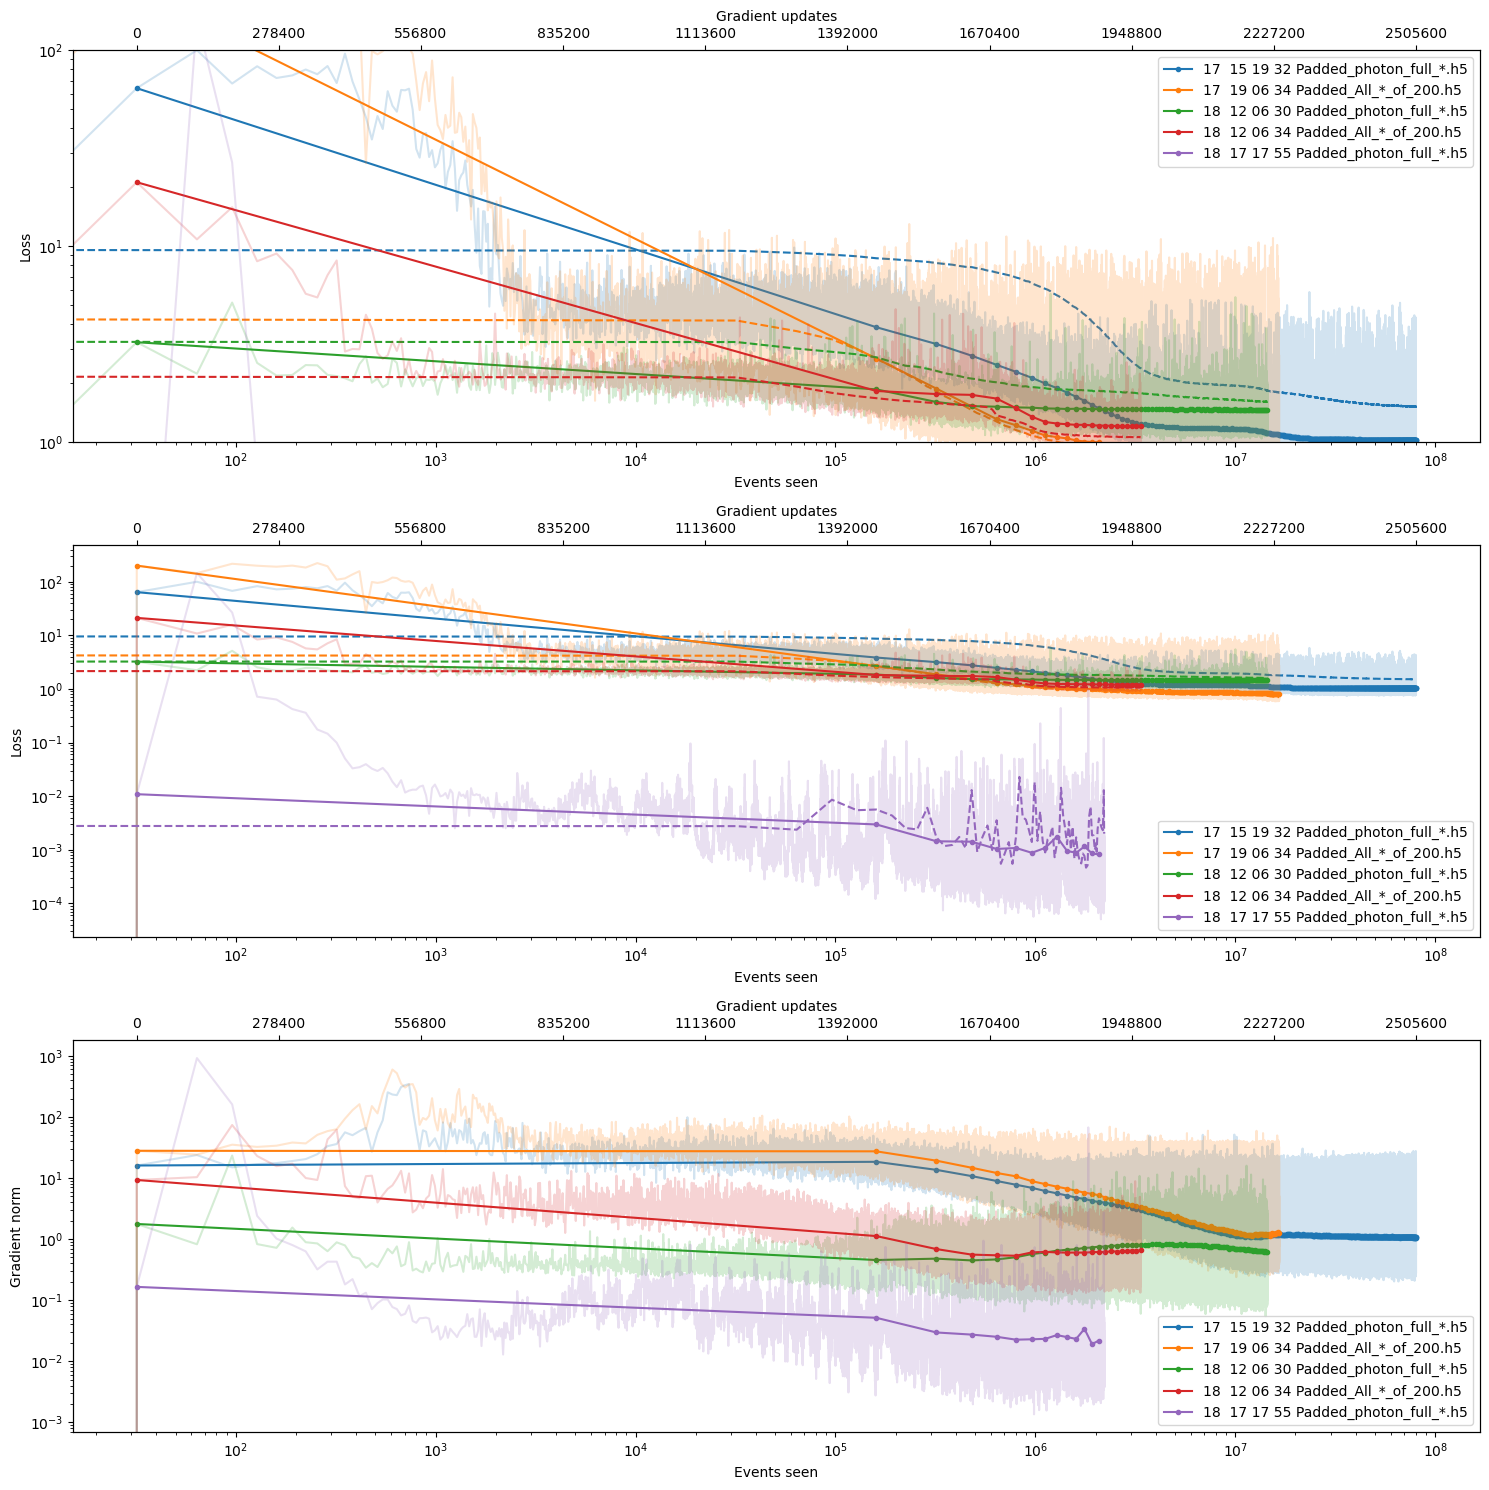

In [45]:
fig, axarr = plt.subplots(3, 1, figsize=(15, 15))
x_name = 'n_events'
y_values = ["loss", "loss", "grad_norm"] #, "ema_decay"]
for i, y_name in enumerate(y_values):
    y_label = pretty[y_name]
    ax = axarr[i]

    # main axis
    longest = trainings[0]
    lowest_val_losses = []
    colour_list = []
    for info, data in zip(infos, trainings):

        c = colours[info]
        colour_list.append(c)
        if len(data[x_name]) > len(longest[x_name]):
            longest = data
        ax.plot(data[x_name], data[y_name], c=c, alpha=0.2)
        s_xs, s_ys = sparse_average(data[x_name], data[y_name])
        ax.plot(s_xs, s_ys, c=c, label=info, marker='.')
        
        if y_name == "loss":
            val_loss = np.mean(data["val_loss"], axis=1)
            val_n_events = data["val_n_events"]
            ax.plot(val_n_events, val_loss, c=c, ls='--')
            lowest_val_losses.append(np.min(val_loss))

    if (i==0) & (y_name == "loss"):
        max_x = longest[x_name][-1]
        #ax.hlines(lowest_val_losses, 0, max_x, colors=colour_list)
        ax.set_ylim(1, 10**2)
    
    if y_name in ["loss", "grad_norm"]:
        ax.semilogy()
    ax.set_xlabel(pretty[x_name])
    ax.set_ylabel(y_label)


    # upper axis
    n_values = len(longest[x_name])
    n_ticks = 10
    value_idxs = np.linspace(0, n_values-1, n_ticks).astype(int)
    positions = [longest[x_name][idx] for idx in value_idxs]
    x_2_name = 'n_updates'
    labels = [longest[x_2_name][idx] for idx in value_idxs]
    ax2 = ax.twiny()          # <- this was missing
    ax2.set_xlim(ax.get_xlim())                   # share the bottom's coordinates
    ax2.set_xticks(positions)
    ax2.set_xticklabels(labels)
    ax2.set_xlabel(pretty[x_2_name])
    ax.legend()
    ax.semilogx()

fig.tight_layout()